# 02. Моделирование и сравнение подходов

Цель ноутбука — сравнить несколько подходов к прогнозированию средней суточной температуры воздуха в Волгограде на одном и том же датасете и оценить, даёт ли нейросетевая модель преимущество по сравнению с классическими статистическими и ML-подходами.

## Постановка задачи и защита от утечки информации

В этой работе используется однодневный прогноз: для даты `t` модель должна предсказать `target_tavg` по информации, доступной не позже конца предыдущего дня.

Это важно по двум причинам:

- лаговые и скользящие признаки уже построены только по прошлым значениям температуры;
- суточные метеопризнаки `tmin`, `tmax`, `prcp_sum`, `pres_mean` и другие сами по себе относятся к текущему дню, поэтому в моделировании они используются только в сдвинутом виде `lag1`, то есть как информация о предыдущем дне.

Разбиение выполняется строго по времени без случайного `shuffle`, поэтому данные из будущего не попадают в обучение.

In [8]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import Holt
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.constants import FIGURES_DIR, MODEL_DATASET_FILENAME, PROCESSED_DATA_DIR, RANDOM_STATE, TABLES_DIR
from src.utils import evaluate_regression, split_train_validation_test

np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

## Шаг 1. Загрузка подготовленного датасета

Этот ноутбук предполагает, что файл `data/processed/volgograd_daily_temperature_dataset.csv` уже создан первым ноутбуком. Если файла нет, нужно сначала выполнить `01_dataset_creation.ipynb`.

In [9]:
dataset_path = PROCESSED_DATA_DIR / MODEL_DATASET_FILENAME
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Файл {dataset_path} не найден. Сначала запустите ноутбук 01_dataset_creation.ipynb."
    )

dataset = pd.read_csv(dataset_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print(f"Загружен датасет: {dataset_path}")
print(f"Размер датасета: {dataset.shape}")
display(dataset.head())

Загружен датасет: /home/nochami/projects/0kursovaya/data/processed/volgograd_daily_temperature_dataset.csv
Размер датасета: (5885, 29)


,date,target_tavg,tmin,tmax,temp_range,prcp_sum,snow,pres_mean,wspd_mean,rhum_mean,tsun_sum,month,dayofyear,dayofweek,season,season_code,doy_sin,doy_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_std_14
0,2010-01-31,-2.745833,-7.0,0.0,7.0,0.0,23,1020.550000,20.100000,99.166667,0,1,31,6,зима,0,0.508356,0.861147,-6.208333,-16.117391,-17.145833,-17.633333,-17.116667,1.508333,-13.157186,-14.840036,-16.461982,3.896986,3.212234
1,2010-02-01,-5.595652,-7.8,-3.9,3.9,0.0,23,1018.825000,23.550000,98.565217,0,2,32,0,зима,0,0.523094,0.852275,-2.745833,-6.208333,-16.117391,-15.466667,-17.204167,2.765217,-8.357186,-12.713251,-15.435494,5.743456,4.860298
2,2010-02-02,-3.943478,-6.1,-2.0,4.1,0.0,23,1018.771429,18.782609,99.826087,0,2,33,1,зима,0,0.537677,0.843151,-5.595652,-2.745833,-6.208333,-15.386957,-16.958333,0.200000,-4.849940,-11.303106,-14.606315,6.152006,5.485373
3,2010-02-03,-8.109091,-13.6,-6.0,7.6,0.0,23,1019.942857,36.654545,96.227273,0,2,34,2,зима,0,0.552101,0.833777,-3.943478,-5.595652,-2.745833,-15.921739,-17.995833,-11.237500,-4.094988,-9.668323,-13.676682,6.401325,6.122005
4,2010-02-04,-14.621739,-17.0,-11.8,5.2,0.0,23,1030.071429,47.895652,84.782609,0,2,35,3,зима,0,0.566362,0.824157,-8.109091,-3.943478,-5.595652,-17.145833,-19.337500,-11.025000,-5.882740,-8.552230,-12.970486,5.780255,6.155593


## Шаг 2. Подготовка признаков для корректного прогноза

В итоговом CSV присутствуют как лаговые признаки, так и суточные метеорологические агрегаты текущего дня. Для прогноза без утечки текущие суточные агрегаты нужно сдвинуть на один день назад, чтобы использовать только информацию, известную к моменту предсказания.

In [10]:
weather_columns = [
    column
    for column in [
        "tmin",
        "tmax",
        "temp_range",
        "prcp_sum",
        "snow",
        "pres_mean",
        "wspd_mean",
        "wpgt_max",
        "rhum_mean",
        "dwpt_mean",
        "tsun_sum",
    ]
    if column in dataset.columns
]

modeling_df = dataset.copy()
for column in weather_columns:
    modeling_df[f"{column}_lag1"] = modeling_df[column].shift(1)

calendar_columns = ["month", "dayofyear", "dayofweek", "season_code", "doy_sin", "doy_cos"]
history_columns = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",
    "rolling_std_14",
]
lagged_weather_columns = [f"{column}_lag1" for column in weather_columns]

feature_columns = calendar_columns + history_columns + lagged_weather_columns
modeling_df = modeling_df.dropna(subset=feature_columns + ["target_tavg"]).reset_index(drop=True)

print("Для моделирования используются только признаки, доступные к моменту прогноза.")
print(f"Количество используемых признаков: {len(feature_columns)}")
display(pd.Series(feature_columns, name="feature_name"))
display(modeling_df[["date", "season", "target_tavg"] + feature_columns[:8]].head())

Для моделирования используются только признаки, доступные к моменту прогноза.
Количество используемых признаков: 26


0               month
1           dayofyear
2           dayofweek
3         season_code
4             doy_sin
5             doy_cos
6               lag_1
7               lag_2
8               lag_3
9               lag_7
10             lag_14
11             lag_30
12     rolling_mean_3
13     rolling_mean_7
14    rolling_mean_14
15      rolling_std_7
16     rolling_std_14
17          tmin_lag1
18          tmax_lag1
19    temp_range_lag1
20      prcp_sum_lag1
21          snow_lag1
22     pres_mean_lag1
23     wspd_mean_lag1
24     rhum_mean_lag1
25      tsun_sum_lag1
Name: feature_name, dtype: str

,date,season,target_tavg,month,dayofyear,dayofweek,season_code,doy_sin,doy_cos,lag_1,lag_2
0,2010-02-01,зима,-5.595652,2,32,0,0,0.523094,0.852275,-2.745833,-6.208333
1,2010-02-02,зима,-3.943478,2,33,1,0,0.537677,0.843151,-5.595652,-2.745833
2,2010-02-03,зима,-8.109091,2,34,2,0,0.552101,0.833777,-3.943478,-5.595652
3,2010-02-04,зима,-14.621739,2,35,3,0,0.566362,0.824157,-8.109091,-3.943478
4,2010-02-05,зима,-16.804167,2,36,4,0,0.580455,0.814292,-14.621739,-8.109091


## Шаг 3. Временное разбиение на train, validation и test

Разбиение делается без случайного перемешивания. Последние 365 дней используются как тестовый интервал, предыдущие 365 дней — как validation, а всё, что раньше, идёт в обучение.

Такой вариант удобен для учебного исследования: у нас есть отдельный интервал для проверки моделей и отдельный финальный интервал для честного сравнения.

In [11]:
train_df, validation_df, test_df = split_train_validation_test(modeling_df)

def interval_summary(frame, name):
    return {
        "subset": name,
        "rows": len(frame),
        "start_date": frame["date"].min().date(),
        "end_date": frame["date"].max().date(),
    }

intervals = pd.DataFrame(
    [
        interval_summary(train_df, "train"),
        interval_summary(validation_df, "validation"),
        interval_summary(test_df, "test"),
    ]
)

display(Markdown("### Интервалы train / validation / test"))
display(intervals)

X_train = train_df[feature_columns]
y_train = train_df["target_tavg"]

X_validation = validation_df[feature_columns]
y_validation = validation_df["target_tavg"]

X_test = test_df[feature_columns]
y_test = test_df["target_tavg"]

### Интервалы train / validation / test

,subset,rows,start_date,end_date
0,train,5154,2010-02-01,2024-03-13
1,validation,365,2024-03-14,2025-03-13
2,test,365,2025-03-14,2026-03-13


## Шаг 4. Дополнительная проверка через TimeSeriesSplit

Для табличной ML-модели дополнительно посмотрим на стабильность качества внутри обучающего интервала с помощью `TimeSeriesSplit`. Здесь важно, что каждая следующая валидационная выборка идёт позже предыдущей, а не перемешивается случайно.

In [12]:
tscv = TimeSeriesSplit(n_splits=5)
cv_records = []

for fold_number, (fit_idx, valid_idx) in enumerate(tscv.split(X_train), start=1):
    cv_model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "regressor",
                HistGradientBoostingRegressor(
                    max_depth=6,
                    learning_rate=0.05,
                    max_iter=300,
                    min_samples_leaf=20,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    cv_model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
    cv_pred = cv_model.predict(X_train.iloc[valid_idx])

    metrics = evaluate_regression(y_train.iloc[valid_idx], cv_pred, f"fold_{fold_number}")
    metrics["rows"] = len(valid_idx)
    cv_records.append(metrics)

cv_results = pd.DataFrame(cv_records)
display(cv_results.round(3))
print(f"Средний MAE по TimeSeriesSplit: {cv_results['mae'].mean():.3f}")
print(f"Средний RMSE по TimeSeriesSplit: {cv_results['rmse'].mean():.3f}")

,model,mae,rmse,bias,rows
0,fold_1,2.042,2.658,-0.021,859
1,fold_2,2.182,2.870,0.111,859
2,fold_3,1.964,2.533,0.006,859
3,fold_4,1.909,2.500,-0.056,859
4,fold_5,2.041,2.666,-0.171,859


Средний MAE по TimeSeriesSplit: 2.028
Средний RMSE по TimeSeriesSplit: 2.646


## Шаг 5. Определение моделей

В исследовании сравниваются пять подходов:

1. Наивный прогноз: значение предыдущего дня.
2. Простой baseline: среднее за последние 7 дней.
3. Экспоненциальное сглаживание Холта.
4. `HistGradientBoostingRegressor` как сильная табличная ML-модель.
5. Компактная полносвязная нейросеть `Dense`.

Для нейросети выбран именно Dense-подход, а не LSTM: в этой постановке уже подготовлены информативные лаговые и скользящие признаки, поэтому табличная сеть достаточно показательна, проще в объяснении и умеренна по ресурсам.

In [13]:
def build_histgb_pipeline():
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "regressor",
                HistGradientBoostingRegressor(
                    max_depth=6,
                    learning_rate=0.05,
                    max_iter=300,
                    min_samples_leaf=20,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

def holt_forecast(history_series, forecast_index):
    fitted_model = Holt(history_series, initialization_method="estimated").fit(optimized=True)
    forecast_values = fitted_model.forecast(len(forecast_index))
    return pd.Series(np.asarray(forecast_values, dtype=float), index=forecast_index, name="holt_prediction")

def build_dense_model(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(1),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mae",
        metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

def temporal_holdout_split(features, target, validation_share=0.15):
    split_index = int(len(features) * (1 - validation_share))
    return (
        features.iloc[:split_index],
        features.iloc[split_index:],
        target.iloc[:split_index],
        target.iloc[split_index:],
    )

def fit_dense_network(X_fit, y_fit, X_valid, y_valid, epochs=100):
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_fit_prepared = imputer.fit_transform(X_fit)
    X_valid_prepared = imputer.transform(X_valid)

    X_fit_prepared = scaler.fit_transform(X_fit_prepared)
    X_valid_prepared = scaler.transform(X_valid_prepared)

    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = build_dense_model(X_fit_prepared.shape[1])

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
        )
    ]

    history = model.fit(
        X_fit_prepared,
        y_fit,
        validation_data=(X_valid_prepared, y_valid),
        epochs=epochs,
        batch_size=32,
        verbose=0,
        shuffle=False,
        callbacks=callbacks,
    )

    return model, imputer, scaler, history

def predict_dense_network(model, imputer, scaler, features):
    prepared = imputer.transform(features)
    prepared = scaler.transform(prepared)
    return model.predict(prepared, verbose=0).reshape(-1)

## Шаг 6. Сравнение моделей на validation

Сначала сравним все подходы на validation-интервале. Это позволяет убедиться, что выбранные настройки адекватны, прежде чем переходить к финальной оценке на test.

In [14]:
validation_predictions = {
    "Наивный прогноз": validation_df["lag_1"].to_numpy(),
    "Скользящее среднее 7 дней": validation_df["rolling_mean_7"].to_numpy(),
    "Экспоненциальное сглаживание Холта": holt_forecast(
        train_df.set_index("date")["target_tavg"],
        validation_df["date"],
    ).to_numpy(),
}

histgb_model = build_histgb_pipeline()
histgb_model.fit(X_train, y_train)
validation_predictions["HistGradientBoosting"] = histgb_model.predict(X_validation)

dense_model, dense_imputer, dense_scaler, dense_history = fit_dense_network(
    X_fit=X_train,
    y_fit=y_train,
    X_valid=X_validation,
    y_valid=y_validation,
)
validation_predictions["Нейросеть Dense"] = predict_dense_network(
    dense_model,
    dense_imputer,
    dense_scaler,
    X_validation,
)

validation_metrics = pd.DataFrame(
    [
        evaluate_regression(y_validation, prediction, model_name)
        for model_name, prediction in validation_predictions.items()
    ]
).sort_values("mae").reset_index(drop=True)

validation_metrics_path = TABLES_DIR / "02_validation_metrics.csv"
validation_metrics.to_csv(validation_metrics_path, index=False)

display(Markdown("### Результаты на validation"))
display(validation_metrics.round(3))
print(f"Таблица validation-метрик сохранена в: {validation_metrics_path}")

### Результаты на validation

,model,mae,rmse,bias
0,Нейросеть Dense,1.642,2.246,0.490
1,HistGradientBoosting,1.754,2.296,-0.173
2,Наивный прогноз,1.858,2.449,-0.038
3,Скользящее среднее 7 дней,2.730,3.486,-0.114
4,Экспоненциальное сглаживание Холта,13.115,16.148,-11.514


Таблица validation-метрик сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_validation_metrics.csv


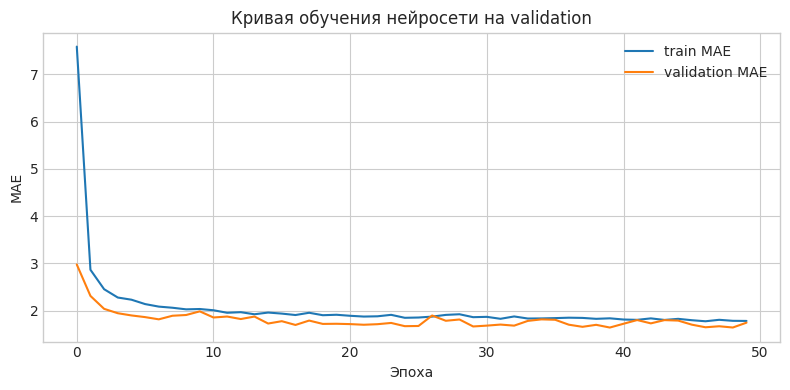

Кривая обучения нейросети сохранена в: /home/nochami/projects/0kursovaya/outputs/figures/02_dense_learning_curve.png


In [15]:
dense_history_path = FIGURES_DIR / "02_dense_learning_curve.png"

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(dense_history.history["loss"], label="train MAE")
ax.plot(dense_history.history["val_loss"], label="validation MAE")
ax.set_title("Кривая обучения нейросети на validation")
ax.set_xlabel("Эпоха")
ax.set_ylabel("MAE")
ax.legend()
fig.tight_layout()
fig.savefig(dense_history_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Кривая обучения нейросети сохранена в: {dense_history_path}")

## Шаг 7. Финальное обучение на train + validation и оценка на test

После проверки на validation обучаем финальные версии моделей на объединённом интервале `train + validation` и сравниваем их на последнем тестовом отрезке.

In [16]:
full_train_df = pd.concat([train_df, validation_df], axis=0).reset_index(drop=True)
X_full_train = full_train_df[feature_columns]
y_full_train = full_train_df["target_tavg"]

test_predictions = {
    "Наивный прогноз": test_df["lag_1"].to_numpy(),
    "Скользящее среднее 7 дней": test_df["rolling_mean_7"].to_numpy(),
    "Экспоненциальное сглаживание Холта": holt_forecast(
        full_train_df.set_index("date")["target_tavg"],
        test_df["date"],
    ).to_numpy(),
}

final_histgb_model = build_histgb_pipeline()
final_histgb_model.fit(X_full_train, y_full_train)
test_predictions["HistGradientBoosting"] = final_histgb_model.predict(X_test)

X_inner_train, X_inner_valid, y_inner_train, y_inner_valid = temporal_holdout_split(
    X_full_train,
    y_full_train,
    validation_share=0.15,
)

final_dense_model, final_dense_imputer, final_dense_scaler, final_dense_history = fit_dense_network(
    X_fit=X_inner_train,
    y_fit=y_inner_train,
    X_valid=X_inner_valid,
    y_valid=y_inner_valid,
)
test_predictions["Нейросеть Dense"] = predict_dense_network(
    final_dense_model,
    final_dense_imputer,
    final_dense_scaler,
    X_test,
)

comparison_table = pd.DataFrame(
    [evaluate_regression(y_test, prediction, model_name) for model_name, prediction in test_predictions.items()]
).sort_values("mae").reset_index(drop=True)

predictions_test = test_df[["date", "season", "target_tavg"]].copy()
for model_name, prediction in test_predictions.items():
    predictions_test[model_name] = prediction

comparison_path = TABLES_DIR / "02_model_comparison.csv"
predictions_path = TABLES_DIR / "02_test_predictions.csv"

comparison_table.to_csv(comparison_path, index=False)
predictions_test.to_csv(predictions_path, index=False)

display(Markdown("### Итоговая таблица сравнения на test"))
display(comparison_table.round(3))

print(f"Таблица test-метрик сохранена в: {comparison_path}")
print(f"Таблица прогнозов на test сохранена в: {predictions_path}")

### Итоговая таблица сравнения на test

,model,mae,rmse,bias
0,HistGradientBoosting,1.846,2.436,0.035
1,Нейросеть Dense,1.894,2.537,0.219
2,Наивный прогноз,2.104,2.808,0.023
3,Скользящее среднее 7 дней,3.284,4.166,0.050
4,Экспоненциальное сглаживание Холта,10.092,12.394,3.469


Таблица test-метрик сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_model_comparison.csv
Таблица прогнозов на test сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_test_predictions.csv


## Шаг 8. Визуальное сравнение прогнозов и ошибок

Ниже строятся графики, которые помогают увидеть не только итоговые числа MAE и RMSE, но и поведение моделей на всём тестовом интервале.

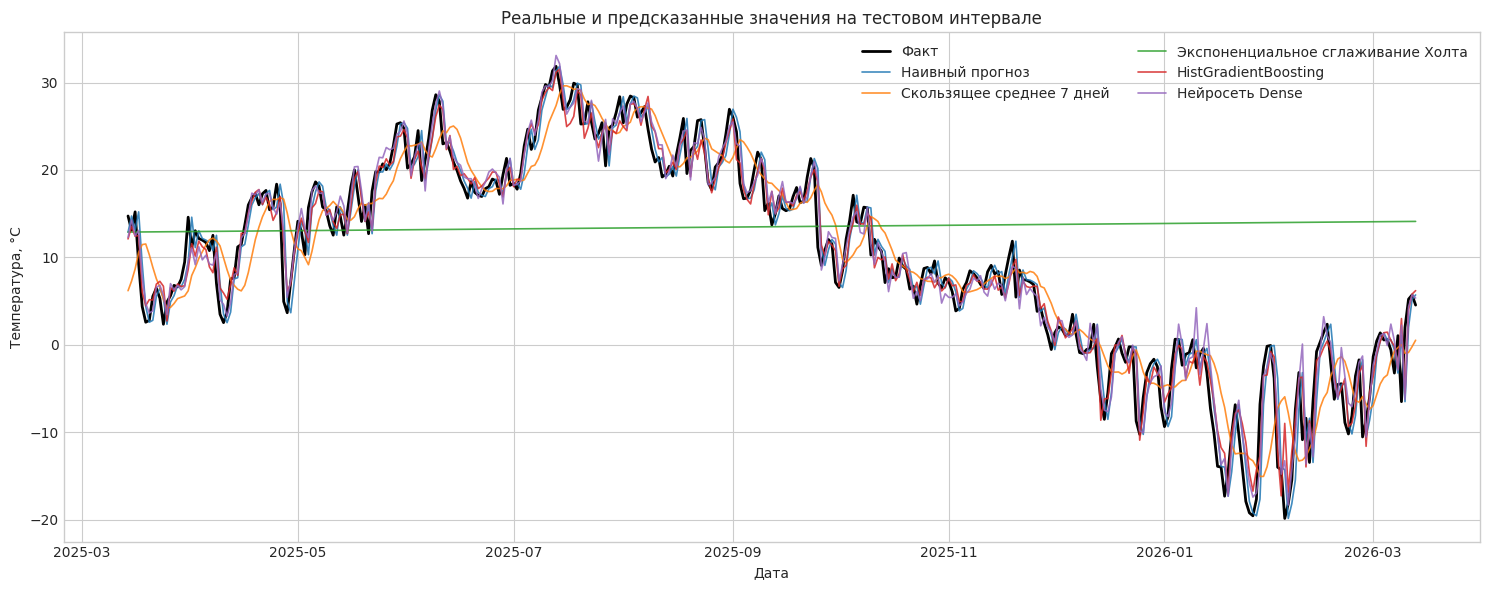

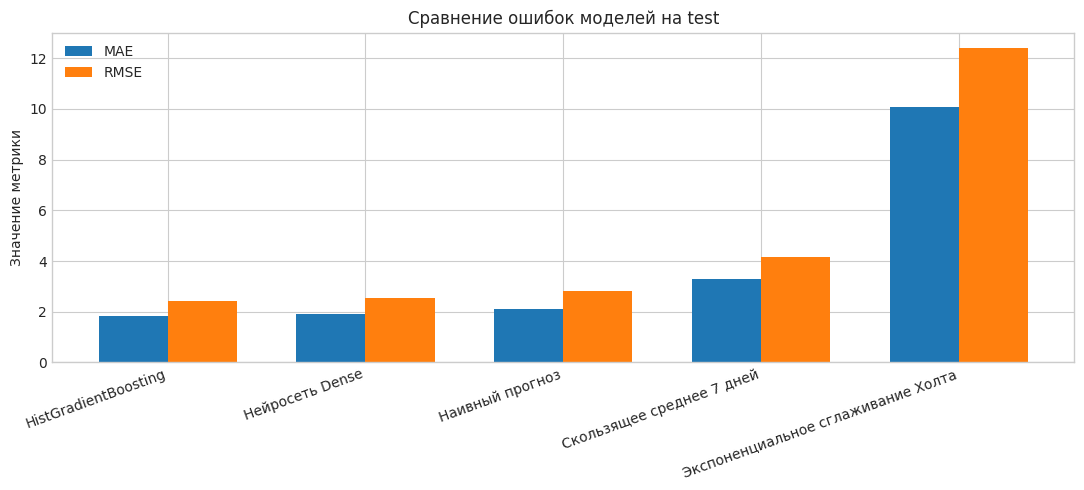

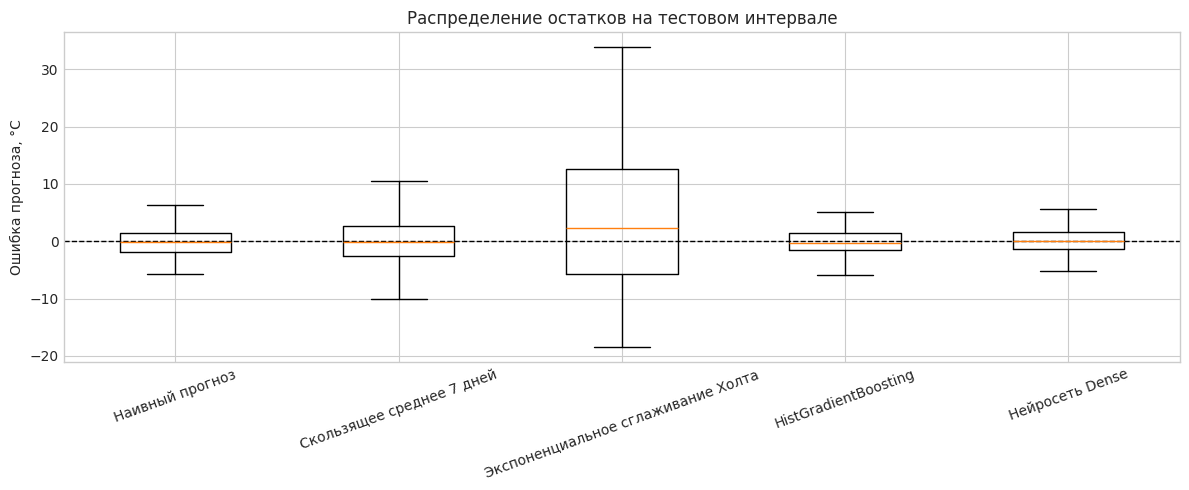

График прогнозов сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_test_predictions.png
График метрик сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_model_metrics.png
График распределения остатков сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_residuals_distribution.png


In [17]:
prediction_figure_path = FIGURES_DIR / "02_test_predictions.png"
metrics_figure_path = FIGURES_DIR / "02_model_metrics.png"
residuals_figure_path = FIGURES_DIR / "02_residuals_distribution.png"

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(predictions_test["date"], predictions_test["target_tavg"], label="Факт", color="black", linewidth=2)
for model_name in test_predictions:
    ax.plot(predictions_test["date"], predictions_test[model_name], label=model_name, linewidth=1.2, alpha=0.85)
ax.set_title("Реальные и предсказанные значения на тестовом интервале")
ax.set_xlabel("Дата")
ax.set_ylabel("Температура, °C")
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(prediction_figure_path, dpi=200, bbox_inches="tight")
plt.show()

x = np.arange(len(comparison_table))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, comparison_table["mae"], width, label="MAE")
ax.bar(x + width / 2, comparison_table["rmse"], width, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(comparison_table["model"], rotation=20, ha="right")
ax.set_title("Сравнение ошибок моделей на test")
ax.set_ylabel("Значение метрики")
ax.legend()
fig.tight_layout()
fig.savefig(metrics_figure_path, dpi=200, bbox_inches="tight")
plt.show()

residuals = pd.DataFrame({"date": predictions_test["date"]})
for model_name in test_predictions:
    residuals[model_name] = predictions_test[model_name] - predictions_test["target_tavg"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot([residuals[model_name] for model_name in test_predictions], labels=list(test_predictions.keys()), showfliers=False)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Распределение остатков на тестовом интервале")
ax.set_ylabel("Ошибка прогноза, °C")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(residuals_figure_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"График прогнозов сохранён в: {prediction_figure_path}")
print(f"График метрик сохранён в: {metrics_figure_path}")
print(f"График распределения остатков сохранён в: {residuals_figure_path}")

## Шаг 9. Анализ ошибок по сезонам и систематическому смещению

Итоговые метрики важны, но для исследовательской работы полезно отдельно понять:

- в какие сезоны модели ошибаются сильнее;
- есть ли у них систематическое завышение или занижение температуры.

### Таблица сезонных ошибок

,model,season,mae_by_season,bias_by_season,rows
0,HistGradientBoosting,весна,1.910,-0.086,92
1,HistGradientBoosting,зима,2.366,0.477,90
2,HistGradientBoosting,лето,1.615,-0.186,92
3,HistGradientBoosting,осень,1.499,-0.055,91
4,Наивный прогноз,весна,2.189,-0.243,92
5,Наивный прогноз,зима,2.789,0.060,90
6,Наивный прогноз,лето,1.771,-0.024,92
7,Наивный прогноз,осень,1.676,0.302,91
8,Нейросеть Dense,весна,1.862,0.127,92
9,Нейросеть Dense,зима,2.576,0.591,90


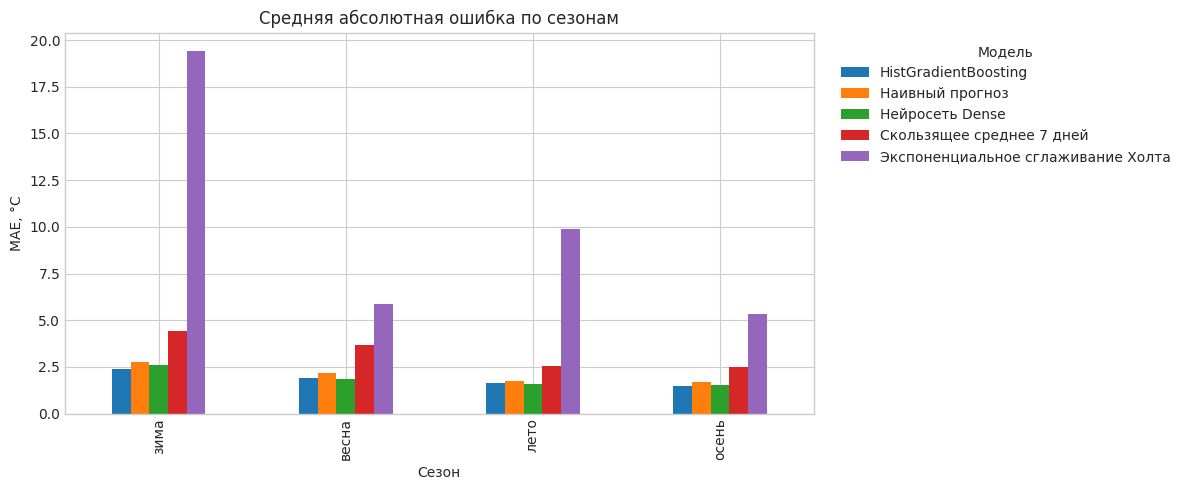

### Систематическое смещение моделей

,model,bias
0,HistGradientBoosting,0.035
1,Нейросеть Dense,0.219
2,Наивный прогноз,0.023
3,Скользящее среднее 7 дней,0.050
4,Экспоненциальное сглаживание Холта,3.469


Таблица сезонных ошибок сохранена в: /home/nochami/projects/0kursovaya/outputs/tables/02_seasonal_error_analysis.csv
График сезонных ошибок сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/02_error_by_season.png


In [18]:
season_records = []
for model_name in test_predictions:
    temp_frame = pd.DataFrame(
        {
            "date": predictions_test["date"],
            "season": predictions_test["season"],
            "model": model_name,
            "absolute_error": (predictions_test[model_name] - predictions_test["target_tavg"]).abs(),
            "residual": predictions_test[model_name] - predictions_test["target_tavg"],
        }
    )
    season_records.append(temp_frame)

seasonal_error_df = pd.concat(season_records, ignore_index=True)
seasonal_summary = seasonal_error_df.groupby(["model", "season"]).agg(
    mae_by_season=("absolute_error", "mean"),
    bias_by_season=("residual", "mean"),
    rows=("absolute_error", "size"),
).reset_index()

seasonal_path = TABLES_DIR / "02_seasonal_error_analysis.csv"
seasonal_summary.to_csv(seasonal_path, index=False)

display(Markdown("### Таблица сезонных ошибок"))
display(seasonal_summary.round(3))

season_order = ["зима", "весна", "лето", "осень"]
pivot_mae = seasonal_summary.pivot(index="season", columns="model", values="mae_by_season").reindex(season_order)

season_figure_path = FIGURES_DIR / "02_error_by_season.png"
fig, ax = plt.subplots(figsize=(12, 5))
pivot_mae.plot(kind="bar", ax=ax)
ax.set_title("Средняя абсолютная ошибка по сезонам")
ax.set_xlabel("Сезон")
ax.set_ylabel("MAE, °C")
ax.legend(title="Модель", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(season_figure_path, dpi=200, bbox_inches="tight")
plt.show()

display(Markdown("### Систематическое смещение моделей"))
display(comparison_table[["model", "bias"]].round(3))

print(f"Таблица сезонных ошибок сохранена в: {seasonal_path}")
print(f"График сезонных ошибок сохранён в: {season_figure_path}")

In [19]:
best_model = comparison_table.iloc[0]
neural_row = comparison_table[comparison_table["model"] == "Нейросеть Dense"].iloc[0]
ml_row = comparison_table[comparison_table["model"] == "HistGradientBoosting"].iloc[0]

if neural_row["mae"] < ml_row["mae"]:
    neural_vs_ml = "Нейросеть показала преимущество перед выбранной классической ML-моделью по MAE."
else:
    neural_vs_ml = "Нейросеть не смогла обойти выбранную классическую ML-модель по MAE."

if abs(neural_row["bias"]) < abs(ml_row["bias"]):
    bias_comment = "По систематическому смещению нейросеть оказалась аккуратнее классической ML-модели."
else:
    bias_comment = "По систематическому смещению нейросеть не дала заметного выигрыша."

summary_text = f"""
## Выводы

Лучшая модель на test по MAE: **{best_model['model']}**.

- {neural_vs_ml}
- {bias_comment}
- Даже если нейросеть не стала лучшей, это нормальный исследовательский результат: для сравнительно небольшого табличного датасета модели на аккуратно подготовленных признаках нередко оказываются не хуже компактной Dense-сети.
- Сезонный анализ помогает увидеть, в какие времена года ошибка возрастает сильнее и где модель начинает систематически завышать или занижать температуру.

Практический вывод: нейросеть имеет смысл сравнивать только на фоне сильных baseline и хорошо подготовленных признаков, а не рассматривать как автоматически лучший вариант.
"""

display(Markdown(summary_text))


## Выводы

Лучшая модель на test по MAE: **HistGradientBoosting**.

- Нейросеть не смогла обойти выбранную классическую ML-модель по MAE.
- По систематическому смещению нейросеть не дала заметного выигрыша.
- Даже если нейросеть не стала лучшей, это нормальный исследовательский результат: для сравнительно небольшого табличного датасета модели на аккуратно подготовленных признаках нередко оказываются не хуже компактной Dense-сети.
- Сезонный анализ помогает увидеть, в какие времена года ошибка возрастает сильнее и где модель начинает систематически завышать или занижать температуру.

Практический вывод: нейросеть имеет смысл сравнивать только на фоне сильных baseline и хорошо подготовленных признаков, а не рассматривать как автоматически лучший вариант.
